# Notebook 05: ML Baseline / Predictive Model

**Purpose:** Train a supervised machine learning baseline model to predict next-step road-level carbon emissions from historical traffic features.

### Problem Formulation
- **Features ($X_t$):** `vehicle_count`, `average_speed`, `total_waiting_time`, `average_waiting_time`, `traffic_flow`, `congestion_indicator`, `rolling_CO2`, `rolling_waiting_time`.
- **Target ($y_{t+1}$):** `total_CO2` at the next time step ($t+1$).
- **Methodology:** Time-aware train-test split (train on first 80% of simulation steps, evaluate on last 20%) to avoid data leakage.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

features_path = Path("../data/processed/rl_features.csv")


### Load Features and Construct Lead Target

In [2]:
df = pd.read_csv(features_path)

# Create next-step target per road segment
df["next_total_CO2"] = df.groupby("road_id")["total_CO2"].shift(-1)

# Drop missing values resulting from shift
df_ml = df.dropna(subset=["next_total_CO2"]).reset_index(drop=True)

features = [
    "vehicle_count", "average_speed", "total_waiting_time", 
    "average_waiting_time", "traffic_flow", "congestion_indicator", 
    "rolling_CO2", "rolling_waiting_time"
]

target = "next_total_CO2"

X = df_ml[features]
y = df_ml[target]


### Time-Aware Train-Test Split

In [3]:
unique_times = sorted(df_ml["simulation_time"].unique())
split_idx = int(len(unique_times) * 0.8)
split_time = unique_times[split_idx]

train_mask = df_ml["simulation_time"] < split_time
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train samples: 806704, Test samples: 350552


### Train & Evaluate Predictors

In [4]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate Models
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Results ---")
    print(f"MAE: {mae:.2f} mg/s")
    print(f"RMSE: {rmse:.2f} mg/s")
    print(f"R² Score: {r2:.4f}")
    return mae, rmse, r2

lr_metrics = evaluate(y_test, y_pred_lr, "Linear Regression")
rf_metrics = evaluate(y_test, y_pred_rf, "Random Forest")


--- Linear Regression Results ---
MAE: 2468.46 mg/s
RMSE: 4094.67 mg/s
R² Score: 0.5818
--- Random Forest Results ---
MAE: 2413.56 mg/s
RMSE: 4072.37 mg/s
R² Score: 0.5863


### Feature Importance

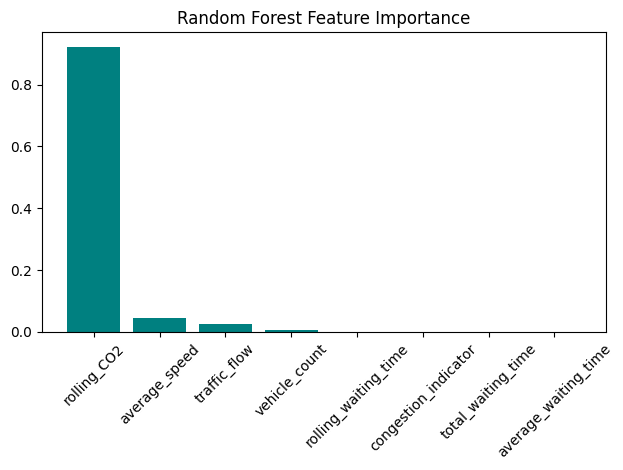

In [5]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Random Forest Feature Importance")
plt.bar(range(len(features)), importances[indices], color="teal", align="center")
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()
